<a href="https://www.kaggle.com/code/lalit7881/lotus-retail-dataset-eda-98?scriptVersionId=338987319" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/fact_orders_2024.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/fact_orders_2022_2023.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/dim_products.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/dim_date.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/dim_employees.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/dim_customers.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/fact_order_details.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/dim_stores.csv
/kaggle/input/datasets/abdelrahmanmahmoud22/lotus-group-retail-star-schema-bi/fact_returns.csv


## Loading dataset

In [2]:
# Import necessary libraries with warnings suppression
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Use Agg backend if using full matplotlib and inline plotting
matplotlib.use('Agg')
%matplotlib inline

from pathlib import Path

# Helper to resolve the data file paths at runtime
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Set seaborn style
sns.set(style="whitegrid")

In [3]:
# Load dim_products.csv
products_path = resolve_data_file(file_name='dim_products.csv')
df_products = pd.read_csv(products_path, delimiter=',', encoding='ascii')
print('Products data loaded:', df_products.shape)

Products data loaded: (345, 10)


In [4]:
# Load dim_employees.csv
employees_path = resolve_data_file(file_name='dim_employees.csv')
df_employees = pd.read_csv(employees_path, delimiter=',', encoding='ascii')
print('Employees data loaded:', df_employees.shape)

Employees data loaded: (216, 8)


In [5]:
# Load fact_orders_2024.csv
orders2024_path = resolve_data_file(file_name='fact_orders_2024.csv')
df_orders2024 = pd.read_csv(orders2024_path, delimiter=',', encoding='ascii')
print('2024 Orders data loaded:', df_orders2024.shape)

2024 Orders data loaded: (4058, 10)


In [6]:
# Load dim_customers.csv
customers_path = resolve_data_file(file_name='dim_customers.csv')
df_customers = pd.read_csv(customers_path, delimiter=',', encoding='ascii')
print('Customer data loaded:', df_customers.shape)

Customer data loaded: (3050, 10)


In [7]:
# Load fact_returns.csv
returns_path = resolve_data_file(file_name='fact_returns.csv')
df_returns = pd.read_csv(returns_path, delimiter=',', encoding='ascii')
print('Returns data loaded:', df_returns.shape)

Returns data loaded: (1056, 7)


In [8]:
# Load fact_orders_2022_2023.csv
orders2022_2023_path = resolve_data_file(file_name='fact_orders_2022_2023.csv')
df_orders2022_2023 = pd.read_csv(orders2022_2023_path, delimiter=',', encoding='ascii')
print('2022-2023 Orders data loaded:', df_orders2022_2023.shape)

2022-2023 Orders data loaded: (7942, 10)


In [9]:
# Load dim_date.csv
date_path = resolve_data_file(file_name='dim_date.csv')
df_date = pd.read_csv(date_path, delimiter=',', encoding='ascii')
print('Date dimension data loaded:', df_date.shape)

Date dimension data loaded: (1096, 13)


In [10]:
# Load fact_order_details.csv
order_details_path = resolve_data_file(file_name='fact_order_details.csv')
df_order_details = pd.read_csv(order_details_path, delimiter=',', encoding='ascii')
print('Order details data loaded:', df_order_details.shape)


Order details data loaded: (25099, 10)


In [11]:
stores_path = resolve_data_file(file_name='dim_stores.csv')
df_stores = pd.read_csv(stores_path, delimiter=',', encoding='ascii')
print('Stores data loaded:', df_stores.shape)

Stores data loaded: (15, 8)


In [12]:
for df, col in [(df_employees, 'hire_date'), (df_customers, 'birth_date'), (df_customers, 'registration_date'), (df_orders2024, 'order_date'), (df_orders2022_2023, 'order_date'), (df_returns, 'return_date')]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [13]:
print('Missing values in products:\n', df_products.isnull().sum())

Missing values in products:
 product_id          0
product_name_raw    0
category            0
subcategory         0
brand               0
unit_price_text     0
unit_price          0
unit_cost           0
stock_qty           0
is_active           0
dtype: int64


In [14]:
print('Missing values in employees:\n', df_employees.isnull().sum())

Missing values in employees:
 employee_id           0
first_name            0
last_name             0
gender                0
role                  0
store_id              0
hire_date             0
monthly_salary_egp    0
dtype: int64


In [15]:
print('Missing values in customers:\n', df_customers.isnull().sum())

Missing values in customers:
 customer_id            0
full_name              0
gender                 0
birth_date           567
phone                  0
email                382
city                   0
region                 0
loyalty_tier           0
registration_date      0
dtype: int64


In [16]:
if 'unit_price_text' in df_products.columns:
    df_products.drop(columns=['unit_price_text'], inplace=True)

## EDA

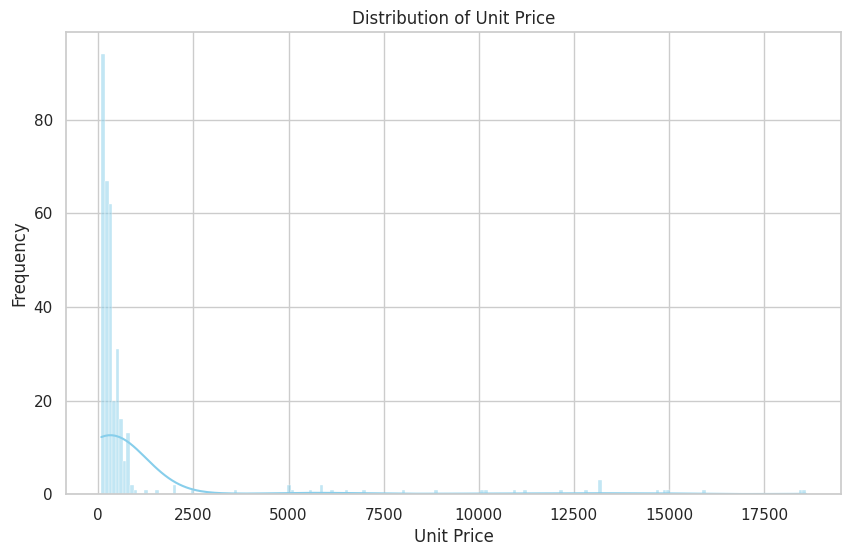

In [17]:
# Example 1: Distribution of unit_price in products
plt.figure(figsize=(10, 6))
sns.histplot(df_products['unit_price'], kde=True, color='skyblue')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

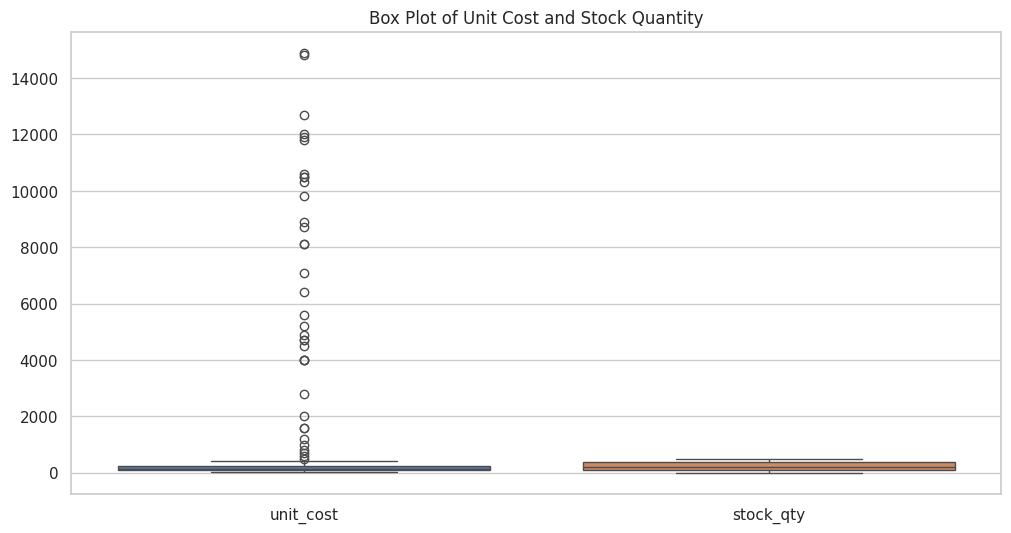

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_products[['unit_cost', 'stock_qty']])
plt.title('Box Plot of Unit Cost and Stock Quantity')
plt.show()

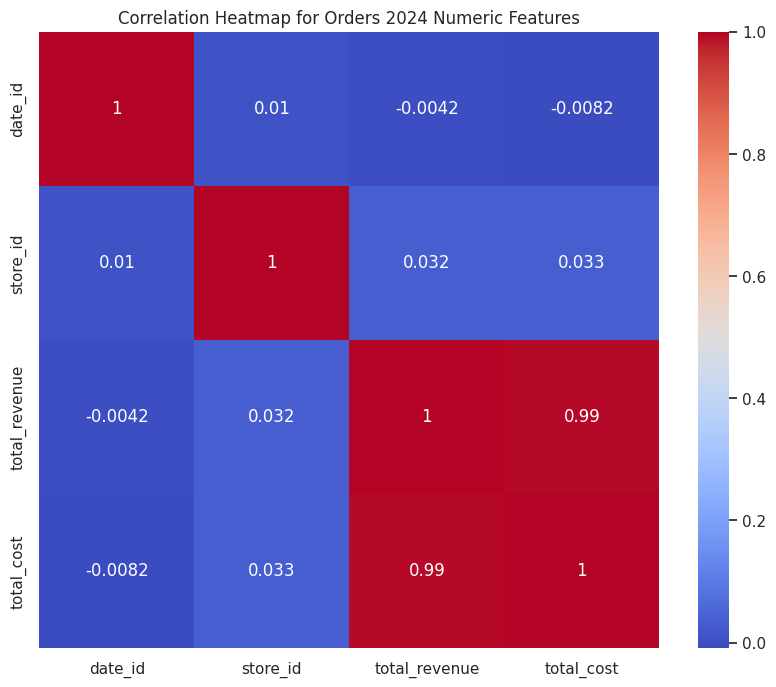

In [19]:
numeric_cols = df_orders2024.select_dtypes(include=[np.number])
if numeric_cols.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    correlation_matrix = numeric_cols.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap for Orders 2024 Numeric Features')
    plt.show()

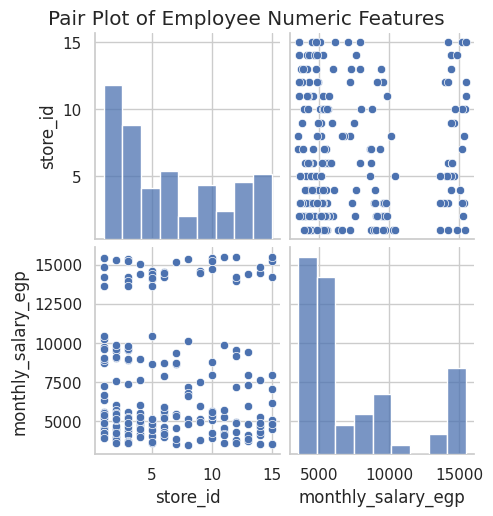

In [20]:
if df_employees.select_dtypes(include=[np.number]).shape[1] >= 2:
    sns.pairplot(df_employees.select_dtypes(include=[np.number]))
    plt.suptitle('Pair Plot of Employee Numeric Features', y=1.02)
    plt.show()

## Feature engineering

R² Score for Total Revenue Predictor: 0.9895532958622614


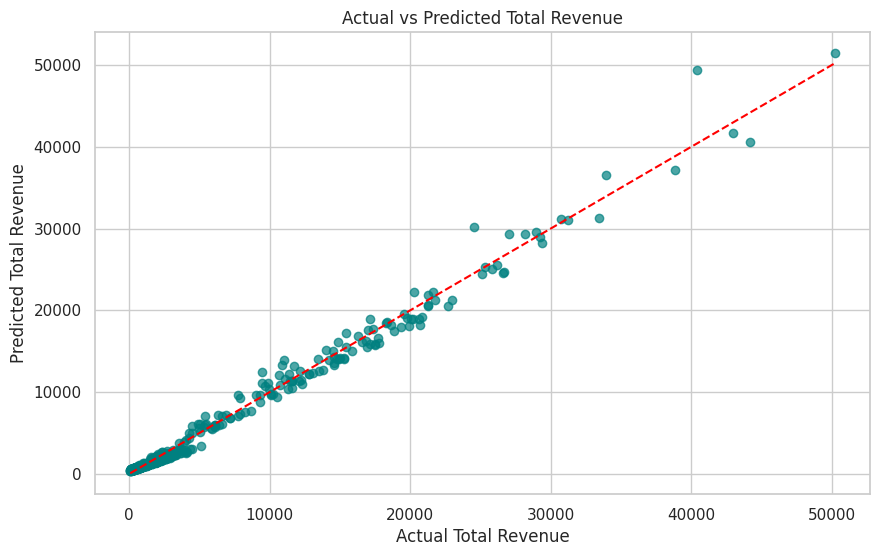

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data for regression on orders2024
df_reg = df_orders2024.copy()

# Select features: total_cost (numeric), store_id (numeric) and payment_method (categorical)
features = ['total_cost', 'store_id', 'payment_method']
target = 'total_revenue'

# Drop rows with missing target or feature values
df_reg = df_reg.dropna(subset=features + [target])

# One-hot encode the payment_method categorical column
df_reg_encoded = pd.get_dummies(df_reg[features], columns=['payment_method'], drop_first=True)

X = df_reg_encoded
y = df_reg[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate the R2 score to evaluate model performance
r2 = r2_score(y_test, y_pred)
print('R² Score for Total Revenue Predictor:', r2)

# Optional: Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel('Actual Total Revenue')
plt.ylabel('Predicted Total Revenue')
plt.title('Actual vs Predicted Total Revenue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.show()

## Thank you..pls upvote!!!!!!!!!